<a href="https://colab.research.google.com/github/shadsavy/Phishingurl/blob/main/Paper_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/arikustiawan/PhishOFE.git
%cd PhishOFE

Cloning into 'PhishOFE'...
remote: Enumerating objects: 863, done.
remote: Counting objects: 100% (863/863), done.
remote: Compressing objects: 100% (408/408), done.
remote: Total 863 (delta 503), reused 765 (delta 447), pack-reused 0 (from 0)
Receiving objects: 100% (863/863), 4.39 MiB | 6.04 MiB/s, done.
Resolving deltas: 100% (503/503), done.
/content/PhishOFE


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.4 MB/s eta 0:00:00


In [ ]:
!ls -la

total 2328
drwxr-xr-x 6 root root    4096 Aug 21 04:11 .
drwxr-xr-x 1 root root    4096 Aug 21 04:11 ..
drwxr-xr-x 2 root root    4096 Aug 21 04:11 dataset
drwxr-xr-x 2 root root    4096 Aug 21 04:11 .devcontainer
-rw-r--r-- 1 root root   11284 Aug 21 04:11 feature.py
drwxr-xr-x 8 root root    4096 Aug 21 04:11 .git
-rw-r--r-- 1 root root   13670 Aug 21 04:11 logo.jpg
-rw-r--r-- 1 root root 2111667 Aug 21 04:11 model.pkl
drwxr-xr-x 2 root root    4096 Aug 21 04:11 pages
-rw-r--r-- 1 root root  194087 Aug 21 04:11 PhishOFE_Model_Building_and_Training.ipynb
-rw-r--r-- 1 root root    3774 Aug 21 04:11 Predict_URL.py
-rw-r--r-- 1 root root     111 Aug 21 04:11 requirements.txt
-rw-r--r-- 1 root root    2134 Aug 21 04:11 styles.css
-rw-r--r-- 1 root root    5205 Aug 21 04:11 training.py


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
import time
import warnings

In [ ]:
df = pd.read_csv("dataset/PhishOFE_ds.csv")
df.dtypes


,0
URL,object
IsHTTPS,int64
IsDomainIP,int64
TLD,object
URLLength,int64
NoOfSubDomain,int64
NoOfDots,int64
NoOfObfuscatedChar,int64
NoOfEqual,int64
NoOfQmark,int64


In [ ]:
def SuspiciousCharRatio(data):
    data['SuspiciousCharRatio'] = (
            data['NoOfObfuscatedChar'] +
            data['NoOfEqual'] +
            data['NoOfQmark'] +
            data['NoOfAmp']
        ) / data['URLLength']
    return data

In [ ]:
def URLComplexityScore(data):
    # Calculate the first term: (URLLength + NoOfSubDomain + NoOfObfuscatedChar) / URLLength
    first_term = (
        data['URLLength'] +
        data['NoOfSubDomain'] +
        data['NoOfObfuscatedChar']
    ) / data['URLLength']

    # Calculate the second term: (NoOfEqual + NoOfAmp) / (NoOfQmark + 1)
    second_term = (
        data['NoOfEqual'] +
        data['NoOfAmp']
    ) / (data['NoOfQmark'] + 1)

    data['URLComplexityScore'] = first_term + second_term

    return data

In [ ]:
def HTMLContentDensity(data):
    data['HTMLContentDensity'] = (
            data['LineLength'] + data['NoOfImage']
        ) / (
            data['NoOfJS'] + data['NoOfCSS'] + data['NoOfiFrame'] + 1
        )
    return data

In [ ]:

def InteractiveElementDensity(data):
    data['InteractiveElementDensity'] = (
            data['HasSubmitButton'] +
            data['HasPasswordField'] +
            data['NoOfPopup']
        ) / (
            data['LineLength'] + data['NoOfImage']
        )
    return data

In [ ]:

df = SuspiciousCharRatio(df)
df = URLComplexityScore(df)
df = HTMLContentDensity(df)
df = InteractiveElementDensity(df)
df.dtypes

,0
URL,object
IsHTTPS,int64
IsDomainIP,int64
TLD,object
URLLength,int64
NoOfSubDomain,int64
NoOfDots,int64
NoOfObfuscatedChar,int64
NoOfEqual,int64
NoOfQmark,int64


In [ ]:
#description of dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
IsHTTPS,101063.0,0.973274,0.161282,0.000000,1.000000,1.000000,1.000000,1.000000e+00
IsDomainIP,101063.0,0.002602,0.050947,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLLength,101063.0,42.180323,122.796863,12.000000,23.000000,27.000000,37.000000,2.552300e+04
NoOfSubDomain,101063.0,0.944945,0.481081,0.000000,1.000000,1.000000,1.000000,1.000000e+01
NoOfDots,101063.0,2.059280,0.802533,1.000000,2.000000,2.000000,2.000000,2.300000e+01
NoOfObfuscatedChar,101063.0,0.505506,1.899502,0.000000,0.000000,0.000000,1.000000,1.940000e+02
NoOfEqual,101063.0,0.257968,1.141472,0.000000,0.000000,0.000000,0.000000,4.700000e+01
NoOfQmark,101063.0,0.088588,0.305593,0.000000,0.000000,0.000000,0.000000,1.700000e+01
NoOfAmp,101063.0,0.170557,0.883987,0.000000,0.000000,0.000000,0.000000,4.300000e+01
NoOfDigits,101063.0,3.181748,17.701250,0.000000,0.000000,0.000000,2.000000,3.413000e+03


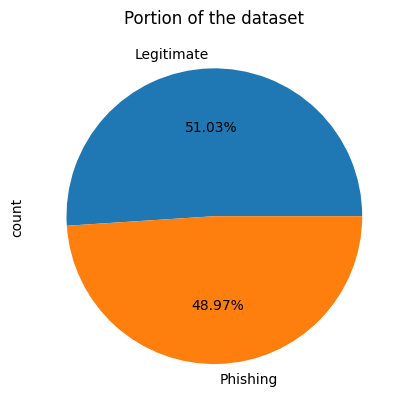

In [ ]:
# Phishing Count in pie chart

df['label'].value_counts().plot(kind='pie', labels=['Legitimate', 'Phishing'], autopct='%1.2f%%')
plt.title("Portion of the dataset")
plt.show()

In [ ]:
df.head()

,URL,IsHTTPS,IsDomainIP,TLD,URLLength,NoOfSubDomain,NoOfDots,NoOfObfuscatedChar,NoOfEqual,NoOfQmark,...,NoOfImage,NoOfJS,NoOfCSS,NoOfURLRedirect,NoOfHyperlink,label,SuspiciousCharRatio,URLComplexityScore,HTMLContentDensity,InteractiveElementDensity
0,https://www.fow.kr,1,0,kr,18,1,2,0,0,0,...,81,16,2,2,57,0,0.0,1.055556,40.526316,0.001299
1,https://www.visa.com.ar,1,0,ar,23,2,3,0,0,0,...,11,31,10,0,11,0,0.0,1.086957,8.214286,0.000000
2,https://www.inflibnet.ac.in,1,0,in,27,2,3,0,0,0,...,42,26,10,0,229,0,0.0,1.074074,23.868421,0.000000
3,https://www.lyrsense.com,1,0,com,24,1,2,0,0,0,...,106,14,1,1,331,0,0.0,1.041667,18.937500,0.000000
4,https://www.61saat.com,1,0,com,22,1,2,0,0,0,...,79,46,4,0,275,0,0.0,1.045455,340.403846,0.000056


In [ ]:
# Define features and target
#X = df.drop(columns=['label','URL'])  # Drop non-numeric and irrelevant columns

d = defaultdict(LabelEncoder)
df = df.apply(lambda x: d[x.name].fit_transform(x))

df_FS = df.copy()

# Define 'y' as the target variable (label column)
y = df_FS['label']
X = df_FS.drop(columns=['label','URL']) # Target variable: 1 for phishing, 0 for legitimate

#colnames = X.columns
#X.head()
df.head()

,URL,IsHTTPS,IsDomainIP,TLD,URLLength,NoOfSubDomain,NoOfDots,NoOfObfuscatedChar,NoOfEqual,NoOfQmark,...,NoOfImage,NoOfJS,NoOfCSS,NoOfURLRedirect,NoOfHyperlink,label,SuspiciousCharRatio,URLComplexityScore,HTMLContentDensity,InteractiveElementDensity
0,64790,1,0,218,5,1,1,0,0,0,...,81,16,2,2,57,0,0,309,5677,21372
1,96993,1,0,49,10,2,2,0,0,0,...,11,31,10,0,11,0,0,404,270,0
2,70121,1,0,200,14,2,2,0,0,0,...,42,26,10,0,229,0,0,370,3110,0
3,75182,1,0,111,11,1,1,0,0,0,...,106,14,1,1,331,0,0,249,2201,0
4,48513,1,0,111,9,1,1,0,0,0,...,79,46,4,0,275,0,0,264,20028,7205


In [ ]:
# Define a ranking function
def ranking(ranks, names, order=1):
    minmax = MinMaxScaler()
    ranks = minmax.fit_transform(order * np.array([ranks]).T).T[0]
    ranks = map(lambda x: round(x, 2), ranks)
    return dict(zip(names, ranks))

# Initialize RandomForestClassifier for Boruta
rf = RandomForestClassifier(
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_depth=5,
    n_estimators="auto"  # Adjust n_estimators to a specific value since 'auto' is not valid for this parameter
)

# Initialize Boruta Feature Selector
feat_selector = BorutaPy(rf, n_estimators='auto', random_state=1)

# Fit Boruta to the dataset
feat_selector.fit(X.values, y.values.ravel())

# Generate feature rankings
boruta_score = ranking(
    list(map(float, feat_selector.ranking_)),
    X.columns,  # Use X.columns to provide feature names
    order=-1
)

# Convert rankings into a DataFrame
boruta_score = pd.DataFrame(list(boruta_score.items()), columns=['Features', 'Score'])
boruta_score = boruta_score.sort_values("Score", ascending=False)

# Display the rankings
print(boruta_score)

                     Features  Score
0                     IsHTTPS    1.0
2                         TLD    1.0
18           HasPasswordField    1.0
3                   URLLength    1.0
4               NoOfSubDomain    1.0
5                    NoOfDots    1.0
6          NoOfObfuscatedChar    1.0
7                   NoOfEqual    1.0
8                   NoOfQmark    1.0
9                     NoOfAmp    1.0
10                 NoOfDigits    1.0
11                 LineLength    1.0
12                   HasTitle    1.0
13                    HasMeta    1.0
14                 HasFavicon    1.0
15      HasExternalFormSubmit    1.0
16               HasCopyright    1.0
17        HasSocialNetworking    1.0
26                     NoOfJS    1.0
19            HasSubmitButton    1.0
20             HasKeywordBank    1.0
21              HasKeywordPay    1.0
22           HasKeywordCrypto    1.0
23                  NoOfPopup    1.0
24                 NoOfiFrame    1.0
25                  NoOfImage    1.0
3

In [ ]:
selected_features = X.columns[feat_selector.support_].tolist()

# Use only the selected features
X_selected = X[selected_features]
print("Selected Features: ", selected_features)

Selected Features:  ['IsHTTPS', 'TLD', 'URLLength', 'NoOfSubDomain', 'NoOfDots', 'NoOfObfuscatedChar', 'NoOfEqual', 'NoOfQmark', 'NoOfAmp', 'NoOfDigits', 'LineLength', 'HasTitle', 'HasMeta', 'HasFavicon', 'HasExternalFormSubmit', 'HasCopyright', 'HasSocialNetworking', 'HasPasswordField', 'HasSubmitButton', 'HasKeywordBank', 'HasKeywordPay', 'HasKeywordCrypto', 'NoOfPopup', 'NoOfiFrame', 'NoOfImage', 'NoOfJS', 'NoOfCSS', 'NoOfURLRedirect', 'NoOfHyperlink', 'SuspiciousCharRatio', 'URLComplexityScore', 'HTMLContentDensity', 'InteractiveElementDensity']


In [ ]:
# Creating holders to store the model performance results
ML_Model = []
ML_Model2 = []
ML_Model3 = []
best_parameter =[]
accuracy = []
f1_score = []
recall = []
precision = []
mcc = []
training_time =[]
prediction_time = []

# Creating holders to store the model performance results for multiple runs
rf_accuracy = []
nb_accuracy = []
kNN_accuracy = []
lr_accuracy = []
dt_accuracy = []
svm_accuracy = []
gb_accuracy = []
lgbm_accuracy = []
xgb_accuracy = []
catB_accuracy = []

rf_precision = []
nb_precision = []
kNN_precision = []
lr_precision = []
dt_precision = []
svm_precision = []
gb_precision = []
lgbm_precision = []
xgb_precision = []
catB_precision = []

rf_recall = []
nb_recall = []
kNN_recall = []
lr_recall = []
dt_recall = []
svm_recall = []
gb_recall = []
lgbm_recall = []
xgb_recall = []
catB_recall = []

rf_f1 = []
nb_f1 = []
kNN_f1 = []
lr_f1 = []
dt_f1 = []
svm_f1 = []
gb_f1 = []
lgbm_f1 = []
xgb_f1 = []
catB_f1 = []

rf_mcc = []
nb_mcc = []
kNN_mcc = []
lr_mcc = []
dt_mcc = []
svm_mcc = []
gb_mcc = []
lgbm_mcc = []
xgb_mcc = []
catB_mcc = []

#function to call for storing the results
def storeResults(model, a,b,c,d,m):
  ML_Model.append(model)
  accuracy.append(round(a, 4))
  f1_score.append(round(b, 4))
  recall.append(round(c, 4))
  precision.append(round(d, 4))
  mcc.append(round(m, 4))

def storeResults2(model, e,f):
  ML_Model2.append(model)
  training_time.append(round(e, 4))
  prediction_time.append(round(f, 4))

def storeBestParam(model, g):
    ML_Model3.append(model)
    best_parameter.append(g)

#number of prepeated runs
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
warnings.filterwarnings("ignore")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80850, 33), (80850,), (20213, 33), (20213,))

In [ ]:
# Random Forest Classifier Model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5, random_state=10)

# Define hyperparameter grid
param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 'log2']
}

# Perform GridSearchCV
grid_searchRF = GridSearchCV(
    estimator=forest,
    param_grid=param_rf,
    cv=3,
    n_jobs=-1,
    verbose=0
)

# Fit GridSearchCV on training data
grid_searchRF.fit(X_train, y_train)

# get best params
best_params = grid_searchRF.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('Random Forest',best_params)

#Train the best model on the training set
best_rf = grid_searchRF.best_estimator_
start_training = time.time()
best_rf.fit(X_train, y_train)
end_training = time.time()
rf_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
#y_train_forest = best_rf.predict(X_train)
y_test_forest = best_rf.predict(X_test)
end_prediction = time.time()
rf_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_forest = metrics.accuracy_score(y_test,y_test_forest)
f1_score_test_forest = metrics.f1_score(y_test,y_test_forest)
recall_score_test_forest= metrics.recall_score(y_test,y_test_forest)
precision_score_test_forest = metrics.precision_score(y_test,y_test_forest)
mcc_test_forest = metrics.matthews_corrcoef(y_test, y_test_forest)

print("Accuracy: {:.3f}".format(acc_test_forest))
print("Precision: {:.3f}".format(precision_score_test_forest))
print("Recall: {:.3f}".format(recall_score_test_forest))
print("F1 Score: {:.3f}".format(f1_score_test_forest))
print("MCC): {:.3f}".format(mcc_test_forest))

Accuracy: 0.957
Precision: 0.967
Recall: 0.943
F1 Score: 0.955
MCC): 0.913


In [ ]:
print(f"Training Time: {rf_training_time:.4f} ms")
print(f"Prediction Time: {rf_prediction_time:.4f} ms")

Training Time: 1.7303 ms
Prediction Time: 0.0382 ms


In [ ]:
storeResults('Random Forest',acc_test_forest,f1_score_test_forest,
             recall_score_test_forest,precision_score_test_forest, mcc_test_forest)

storeResults2('Random Forest', rf_training_time,rf_prediction_time)

In [ ]:
df_rf = pd.DataFrame({
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1,
    "MCC": rf_mcc
})
print(df_rf)

Empty DataFrame
Columns: [Accuracy, Precision, Recall, F1-Score, MCC]
Index: []


In [ ]:
# Naive Bayes Classifier Model
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

# instantiate the model
nb= GaussianNB()

param_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Perform GridSearchCV
grid_searchNB = GridSearchCV(
    estimator=nb,
    param_grid=param_nb,
    cv=3,
    n_jobs=-1,
    verbose=0
)
# fit the model
grid_searchNB.fit(X_train, y_train)

# get best params
best_params = grid_searchNB.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('Naive Bayes',best_params)

# Train the best model on the training set
best_nb = grid_searchNB.best_estimator_
start_training = time.time()
best_nb.fit(X_train, y_train)
end_training = time.time()
nb_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_nb = best_nb.predict(X_test)
end_prediction = time.time()
nb_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'var_smoothing': 1e-08}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_nb = metrics.accuracy_score(y_test,y_test_nb)
f1_score_test_nb = metrics.f1_score(y_test,y_test_nb)
recall_score_test_nb = metrics.recall_score(y_test,y_test_nb)
precision_score_test_nb = metrics.precision_score(y_test,y_test_nb)
mcc_test_nb = metrics.matthews_corrcoef(y_test, y_test_nb)

print("Accuracy: {:.3f}".format(acc_test_nb))
print("Precision: {:.3f}".format(precision_score_test_nb))
print("Recall: {:.3f}".format(recall_score_test_nb))
print("F1 Score: {:.3f}".format(f1_score_test_nb))
print("MCC): {:.3f}".format(mcc_test_nb))

Accuracy: 0.907
Precision: 0.944
Recall: 0.863
F1 Score: 0.901
MCC): 0.817


In [ ]:
print(f"Training Time: {nb_training_time:.4f} ms")
print(f"Prediction Time: {nb_prediction_time:.4f} ms")

Training Time: 0.0478 ms
Prediction Time: 0.0060 ms


In [ ]:
storeResults('Naive Bayes',acc_test_nb,f1_score_test_nb,
             recall_score_test_nb,precision_score_test_nb, mcc_test_nb)

storeResults2('Naive Bayes', nb_training_time,nb_prediction_time)

In [ ]:
# K-Nearest Neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model
knn = KNeighborsClassifier()

# Define hyperparameter grid
param_knn = {
    'n_neighbors': [3, 5],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

# Perform GridSearchCV
grid_searchKNN = GridSearchCV(
    estimator=knn,
    param_grid=param_knn,
    cv=3,
    n_jobs=1,
    verbose=0
)

# Fit GridSearchCV on training data
grid_searchKNN.fit(X_train, y_train)

# get best params
best_params = grid_searchKNN.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('kNN',best_params)

# Train the best model on the training set
best_knn = grid_searchKNN.best_estimator_
start_training = time.time()
best_knn.fit(X_train, y_train)
end_training = time.time()
knn_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_knn = best_knn.predict(X_test)
end_prediction = time.time()

knn_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_knn = metrics.accuracy_score(y_test,y_test_knn)
f1_score_test_knn = metrics.f1_score(y_test,y_test_knn)
recall_score_test_knn = metrics.recall_score(y_test,y_test_knn)
precision_score_test_knn = metrics.precision_score(y_test,y_test_knn)
mcc_test_knn = metrics.matthews_corrcoef(y_test, y_test_knn)

print("Accuracy: {:.3f}".format(acc_test_knn))
print("Precision: {:.3f}".format(precision_score_test_knn))
print("Recall: {:.3f}".format(recall_score_test_knn))
print("F1 Score: {:.3f}".format(f1_score_test_knn))
print("MCC): {:.3f}".format(mcc_test_knn))

Accuracy: 0.954
Precision: 0.960
Recall: 0.946
F1 Score: 0.953
MCC): 0.909


In [ ]:
print(f"Training Time: {knn_training_time:.4f} ms")
print(f"Prediction Time: {knn_prediction_time:.4f} ms")

Training Time: 0.0092 ms
Prediction Time: 21.5689 ms


In [ ]:
storeResults('K-Nearest Neighbors',acc_test_knn,f1_score_test_knn,
             recall_score_test_knn,precision_score_test_knn, mcc_test_knn)

storeResults2('K-Nearest Neighbors',knn_training_time,knn_prediction_time)

In [ ]:
# Decision Tree Classifier model
from sklearn.tree import DecisionTreeClassifier

# instantiate the model
tree = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_tree = {
    'max_depth': [50, 100],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini'],
    'max_features': ['sqrt']
}

# Perform GridSearchCV
grid_searchDT = GridSearchCV(
    estimator=tree,
    param_grid=param_tree,
    cv=3,
    n_jobs=-1,
    verbose=0
)

# Fit GridSearchCV on training data
grid_searchDT.fit(X_train, y_train)

# get best params
best_params = grid_searchDT.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('Decision Tree',best_params)

# Train the best model on the training set
best_tree = grid_searchDT.best_estimator_

start_training = time.time()
best_tree.fit(X_train, y_train)
end_training = time.time()
tree_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_tree = best_tree.predict(X_test)
end_prediction = time.time()
tree_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'criterion': 'gini', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_tree = metrics.accuracy_score(y_test,y_test_tree)
f1_score_test_tree = metrics.f1_score(y_test,y_test_tree)
recall_score_test_tree = metrics.recall_score(y_test,y_test_tree)
precision_score_test_tree = metrics.precision_score(y_test,y_test_tree)
mcc_test_tree = metrics.matthews_corrcoef(y_test, y_test_tree)

print("Accuracy: {:.3f}".format(acc_test_tree))
print("Precision: {:.3f}".format(precision_score_test_tree))
print("Recall: {:.3f}".format(recall_score_test_tree))
print("F1 Score: {:.3f}".format(f1_score_test_tree))
print("MCC): {:.3f}".format(mcc_test_tree))

Accuracy: 0.981
Precision: 0.984
Recall: 0.977
F1 Score: 0.981
MCC): 0.962


In [ ]:
print(f"Training Time: {tree_training_time:.4f} ms")
print(f"Prediction Time: {tree_prediction_time:.4f} ms")

Training Time: 0.1743 ms
Prediction Time: 0.0046 ms


In [ ]:
storeResults('Decision Tree',acc_test_tree,f1_score_test_tree,
             recall_score_test_tree,precision_score_test_tree,mcc_test_tree)

storeResults2('Decision Tree',tree_training_time,tree_prediction_time)

In [ ]:
# Linear regression model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# instantiate the model
lr = LogisticRegression(verbose=0)

# Define hyperparameter grid
param_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

# Perform GridSearchCV
grid_searchLR = GridSearchCV(
    estimator=lr,
    param_grid=param_lr,
    cv=3,
    n_jobs=-1,
    verbose=0
)

# Fit GridSearchCV on training data
grid_searchLR.fit(X_train_scaled, y_train)

# get best params
best_params = grid_searchLR.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('Logistic Regression',best_params)

# Train the best model on the training set
best_log = grid_searchLR.best_estimator_
start_training = time.time()
best_log.fit(X_train_scaled, y_train)
end_training = time.time()
log_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_log = best_log.predict(X_test_scaled)
end_prediction = time.time()
log_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'C': 100, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_log = metrics.accuracy_score(y_test,y_test_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
mcc_test_log = metrics.matthews_corrcoef(y_test, y_test_log)

print("Accuracy: {:.3f}".format(acc_test_log))
print("Precision: {:.3f}".format(precision_score_test_log))
print("Recall: {:.3f}".format(recall_score_test_log))
print("F1 Score: {:.3f}".format(f1_score_test_log))
print("MCC): {:.3f}".format(mcc_test_log))

Accuracy: 0.955
Precision: 0.962
Recall: 0.944
F1 Score: 0.953
MCC): 0.909


In [ ]:
# Support Vector Classifier model
from sklearn.svm import SVC

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# defining parameter range
svc = SVC(verbose=False,random_state=42)

# Define hyperparameter grid
param_svc = {
    'C': [1.0, 1, 10],
    'kernel': ['linear','rbf'],
    'class_weight':['balanced'],
    'gamma':['scale']
}

# Perform GridSearchCV
grid_searchSVM = GridSearchCV(
    estimator=svc,
    param_grid=param_svc,
    cv=3,
    n_jobs=-1,
    verbose=0
)
# Fit GridSearchCV on training data
grid_searchSVM.fit(X_train_scaled, y_train)

# get best params
best_params = grid_searchSVM.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('SVM',best_params)

# Train the best model on the training set
best_svc = grid_searchSVM.best_estimator_

start_training = time.time()
best_svc.fit(X_train_scaled, y_train)
end_training = time.time()
svm_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_svc = best_svc.predict(X_test_scaled)

end_prediction = time.time()

svm_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_svc = metrics.accuracy_score(y_test,y_test_svc)
f1_score_test_svc = metrics.f1_score(y_test,y_test_svc)
recall_score_test_svc = metrics.recall_score(y_test,y_test_svc)
precision_score_test_svc = metrics.precision_score(y_test,y_test_svc)
mcc_test_svc = metrics.matthews_corrcoef(y_test, y_test_svc)

print("Accuracy: {:.3f}".format(acc_test_svc))
print("Precision: {:.3f}".format(precision_score_test_svc))
print("Recall: {:.3f}".format(recall_score_test_svc))
print("F1 Score: {:.3f}".format(f1_score_test_svc))
print("MCC): {:.3f}".format(mcc_test_svc))

Accuracy: 0.987
Precision: 0.987
Recall: 0.985
F1 Score: 0.986
MCC): 0.973


In [ ]:
print(f"Training Time: {svm_training_time:.4f} ms")
print(f"Prediction Time: {svm_prediction_time:.4f} ms")

Training Time: 44.5720 ms
Prediction Time: 7.1783 ms


In [ ]:
storeResults('Support Vector Machines (SVM)',acc_test_svc,f1_score_test_svc,
             recall_score_test_svc,precision_score_test_svc,mcc_test_svc)

storeResults2('Support Vector Machines (SVM)',svm_training_time,svm_prediction_time)

In [ ]:
# Gradient Boosting Classifier Model
from sklearn.ensemble import GradientBoostingClassifier

# instantiate the model
gbc = GradientBoostingClassifier(random_state=42)

# Define hyperparameter grid
param_gbc = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.7],
    'max_depth': [1, 2, 4],
}

# Perform GridSearchCV
grid_searchGB = GridSearchCV(
    estimator=gbc,
    param_grid=param_gbc,
    cv=3,
    n_jobs=-1,
    verbose=0
)

# Fit GridSearchCV on training data
grid_searchGB.fit(X_train, y_train)

# get best params
best_params = grid_searchGB.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('Gradient Boosting',best_params)

# Train the best model on the training set
best_gbc = grid_searchGB.best_estimator_
start_training = time.time()
best_gbc.fit(X_train, y_train)
end_training = time.time()
gbc_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_gbc = best_gbc.predict(X_test)
end_prediction = time.time()
gbc_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'learning_rate': 0.7, 'max_depth': 4, 'n_estimators': 100}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_gbc = metrics.accuracy_score(y_test,y_test_gbc)
f1_score_test_gbc = metrics.f1_score(y_test,y_test_gbc)
recall_score_test_gbc = metrics.recall_score(y_test,y_test_gbc)
precision_score_test_gbc = metrics.precision_score(y_test,y_test_gbc)
mcc_test_gbc = metrics.matthews_corrcoef(y_test, y_test_gbc)

print("Accuracy: {:.3f}".format(acc_test_gbc))
print("Precision: {:.3f}".format(precision_score_test_gbc))
print("Recall: {:.3f}".format(recall_score_test_gbc))
print("F1 Score: {:.3f}".format(f1_score_test_gbc))
print("MCC): {:.3f}".format(mcc_test_gbc))

Accuracy: 0.993
Precision: 0.994
Recall: 0.992
F1 Score: 0.993
MCC): 0.986


In [ ]:
print(f"Training Time: {gbc_training_time:.4f} ms")
print(f"Prediction Time: {gbc_prediction_time:.4f} ms")

Training Time: 25.6073 ms
Prediction Time: 0.0347 ms


In [ ]:
storeResults('Gradient Boosting',acc_test_gbc,f1_score_test_gbc,
             recall_score_test_gbc,precision_score_test_gbc,mcc_test_gbc)

storeResults2('Gradient Boosting',gbc_training_time,gbc_prediction_time)

In [ ]:
# LightGBM Classifier model
from lightgbm import LGBMClassifier

# Instantiate the model
lgbm = LGBMClassifier(verbose=0,random_state=42)

# Define hyperparameter grid
param_lgbm = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.7],
    'max_depth': [-1, 2, 4],
}

# Perform GridSearchCV
grid_searchGBM = GridSearchCV(
    estimator=lgbm,
    param_grid=param_lgbm,
    cv=3,
    n_jobs=-1,
    verbose=0
)

# Fit GridSearchCV on training data
grid_searchGBM.fit(X_train, y_train)

# get best params
best_params = grid_searchGBM.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('LightGBM',best_params)

# Train the best model on the training set
best_lgbm = grid_searchGBM.best_estimator_
start_training = time.time()
best_lgbm.fit(X_train, y_train)
end_training = time.time()
lgbm_training_time = end_training - start_training

# Predicting the target value from the model for the samples
start_prediction = time.time()
y_test_lgbm = best_lgbm.predict(X_test)
end_prediction = time.time()
lgbm_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_lgbm = metrics.accuracy_score(y_test,y_test_lgbm)
f1_score_test_lgbm = metrics.f1_score(y_test,y_test_lgbm)
recall_score_test_lgbm = metrics.recall_score(y_test,y_test_lgbm)
precision_score_test_lgbm = metrics.precision_score(y_test,y_test_lgbm)
mcc_test_lgbm = metrics.matthews_corrcoef(y_test, y_test_lgbm)

print("Accuracy: {:.3f}".format(acc_test_lgbm))
print("Precision: {:.3f}".format(precision_score_test_lgbm))
print("Recall: {:.3f}".format(recall_score_test_lgbm))
print("F1 Score: {:.3f}".format(f1_score_test_lgbm))
print("MCC): {:.3f}".format(mcc_test_lgbm))

In [ ]:
print(f"Training Time: {lgbm_training_time:.4f} ms")
print(f"Prediction Time: {lgbm_prediction_time:.4f} ms")

In [ ]:
storeResults('LightGBM',acc_test_lgbm,f1_score_test_lgbm,
             recall_score_test_lgbm,precision_score_test_lgbm,mcc_test_lgbm )

storeResults2('LightGBM',lgbm_training_time,lgbm_prediction_time)

In [ ]:
#  XGBoost Classifier Model
from xgboost import XGBClassifier

# instantiate the model
xgb = XGBClassifier()

# Define hyperparameter grid
param_xgb = {
    'n_estimators': [50,100],
    'learning_rate': [0.01, 0.1, 0.7],
}

# Perform GridSearchCV
grid_searchXGB = GridSearchCV(
    estimator=xgb,
    param_grid=param_xgb,
    cv=3,
    n_jobs=-1,
    verbose=0
)

# Fit GridSearchCV on training data
grid_searchXGB.fit(X_train, y_train)

# get best params
best_params = grid_searchXGB.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('XGBoost',best_params)

# Train the best model on the training set
best_xgb = grid_searchXGB.best_estimator_
start_training = time.time()
best_xgb.fit(X_train, y_train)
end_training = time.time()
xgb_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_xgb = best_xgb.predict(X_test)
end_prediction = time.time()
xgb_prediction_time = end_prediction - start_prediction

In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_xgb = metrics.accuracy_score(y_test,y_test_xgb)
f1_score_test_xgb = metrics.f1_score(y_test,y_test_xgb)
recall_score_test_xgb = metrics.recall_score(y_test,y_test_xgb)
precision_score_test_xgb = metrics.precision_score(y_test,y_test_xgb)
mcc_test_xgb = metrics.matthews_corrcoef(y_test, y_test_xgb)

print("Accuracy: {:.3f}".format(acc_test_xgb))
print("Precision: {:.3f}".format(precision_score_test_xgb))
print("Recall: {:.3f}".format(recall_score_test_xgb))
print("F1 Score: {:.3f}".format(f1_score_test_xgb))
print("MCC): {:.3f}".format(mcc_test_xgb))

Accuracy: 0.995
Precision: 0.997
Recall: 0.994
F1 Score: 0.995
MCC): 0.991


In [ ]:
print(f"Training Time: {xgb_training_time:.4f} ms")
print(f"Prediction Time: {xgb_prediction_time:.4f} ms")

In [ ]:
storeResults('XGBoost',acc_test_xgb,f1_score_test_xgb,
             recall_score_test_xgb,precision_score_test_xgb,mcc_test_xgb)

storeResults2('XGBoost',xgb_training_time,xgb_prediction_time)

In [ ]:
from catboost import CatBoostClassifier

# instantiate the model
catB = CatBoostClassifier(verbose=False)

# Define the parameter grid for hyperparameter tuning
param_catB = {
    'learning_rate': [0.05, 0.1],
    'depth': [6, 8],
    'iterations': [200, 500],
    'l2_leaf_reg': [1, 3],
    'border_count': [32, 64]
}

# Instantiate GridSearchCV
grid_searchCB = GridSearchCV(
    estimator=catB,
    param_grid=param_catB,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=0
)

# Perform the grid search
grid_searchCB.fit(X_train, y_train)

# get best params
best_params = grid_searchCB.best_params_
print("Best hyperparameters:", best_params)
storeBestParam('CatBoost',best_params)

# Evaluate the best model on the test set
best_cat = grid_searchCB.best_estimator_
start_training = time.time()
best_cat.fit(X_train, y_train)
end_training = time.time()
cat_training_time = end_training - start_training

#predicting the target value from the model for the samples
start_prediction = time.time()
y_test_cat = best_cat.predict(X_test)
end_prediction = time.time()
cat_prediction_time = end_prediction - start_prediction

Best hyperparameters: {'border_count': 64, 'depth': 8, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


In [ ]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_test_cat = metrics.accuracy_score(y_test,y_test_cat)
f1_score_test_cat = metrics.f1_score(y_test,y_test_cat)
recall_score_test_cat = metrics.recall_score(y_test,y_test_cat)
precision_score_test_cat = metrics.precision_score(y_test,y_test_cat)
mcc_test_cat = metrics.matthews_corrcoef(y_test, y_test_cat)

print("Accuracy: {:.3f}".format(acc_test_cat))
print("Precision: {:.3f}".format(precision_score_test_cat))
print("Recall: {:.3f}".format(recall_score_test_cat))
print("F1 Score: {:.3f}".format(f1_score_test_cat))
print("MCC): {:.3f}".format(mcc_test_cat))

Accuracy: 0.995
Precision: 0.997
Recall: 0.992
F1 Score: 0.995
MCC): 0.990


In [ ]:
print(f"Training Time: {cat_training_time:.4f} ms")
print(f"Prediction Time: {cat_prediction_time:.4f} ms")

Training Time: 14.3812 ms
Prediction Time: 0.0217 ms


In [ ]:
storeResults('Catboost',acc_test_cat,f1_score_test_cat,
             recall_score_test_cat,precision_score_test_cat,mcc_test_cat)

storeResults2('Catboost',cat_training_time,cat_prediction_time)

In [ ]:
# Stacking Classifier Model
from sklearn.ensemble import StackingClassifier

# Define base estimators (best-performing models from previous steps)
estimators = [
    ('xgb', best_xgb),
    ('lgbm', best_lgbm),
    ('cat', best_cat)
]

# Instantiate the StackingClassifier with LogisticRegression as final estimator
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42, solver='liblinear'),
    cv=3, # Use 3-fold cross-validation for stacking
    n_jobs=-1,
    verbose=0
)

# Train the Stacking Classifier
start_training = time.time()
stacking_classifier.fit(X_train, y_train)
end_training = time.time()
stack_training_time = end_training - start_training

# Predicting the target value from the model for the samples
start_prediction = time.time()
y_test_stack = stacking_classifier.predict(X_test)
end_prediction = time.time()
stack_prediction_time = end_prediction - start_prediction

In [ ]:
# Computing the accuracy, f1_score, Recall, precision of the Stacking Classifier performance
acc_test_stack = metrics.accuracy_score(y_test, y_test_stack)
f1_score_test_stack = metrics.f1_score(y_test, y_test_stack)
recall_score_test_stack = metrics.recall_score(y_test, y_test_stack)
precision_score_test_stack = metrics.precision_score(y_test, y_test_stack)
mcc_test_stack = metrics.matthews_corrcoef(y_test, y_test_stack)

print("Stacking Classifier Performance:")
print(f"Accuracy: {acc_test_stack:.3f}")
print(f"Precision: {precision_score_test_stack:.3f}")
print(f"Recall: {recall_score_test_stack:.3f}")
print(f"F1 Score: {f1_score_test_stack:.3f}")
print(f"MCC: {mcc_test_stack:.3f}")

Stacking Classifier Performance:
Accuracy: 0.995
Precision: 0.997
Recall: 0.993
F1 Score: 0.995
MCC: 0.991


In [ ]:
print(f"Training Time: {stack_training_time:.4f} ms")
print(f"Prediction Time: {stack_prediction_time:.4f} ms")

Training Time: 56.0397 ms
Prediction Time: 0.1767 ms


In [ ]:
storeResults('Stacking Classifier', acc_test_stack, f1_score_test_stack,
             recall_score_test_stack, precision_score_test_stack, mcc_test_stack)

storeResults2('Stacking Classifier', stack_training_time, stack_prediction_time)
storeBestParam('Stacking Classifier', {'base_estimators': ['XGBoost', 'LightGBM', 'CatBoost'], 'final_estimator': 'LogisticRegression'})

In [ ]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'f1_score' : f1_score,
                        'MCC' : mcc,
                      })
display(result)

result2 = pd.DataFrame({ 'ML Model' : ML_Model2,
                        'Training Time' : training_time,
                        'Prediction Time' : prediction_time,
                      })
display(result2)

resultBestParam = pd.DataFrame({ 'ML Model' : ML_Model3,
                        'Best Parameter' : best_parameter,
                      })
display(resultBestParam)

,ML Model,Accuracy,Precision,Recall,f1_score,MCC
0,Random Forest,0.9565,0.9672,0.9433,0.9551,0.9132
1,Naive Bayes,0.9073,0.9436,0.8626,0.9013,0.8171
2,K-Nearest Neighbors,0.9544,0.9603,0.9462,0.9532,0.9088
3,Decision Tree,0.9812,0.9841,0.9774,0.9807,0.9623
4,Support Vector Machines (SVM),0.9865,0.9873,0.9853,0.9863,0.9731
5,Gradient Boosting,0.9929,0.9936,0.9918,0.9927,0.9857
6,LightGBM,0.9933,0.9951,0.9912,0.9932,0.9866
7,XGBoost,0.9953,0.9969,0.9935,0.9952,0.9906
8,Catboost,0.9948,0.9972,0.9922,0.9947,0.9896
9,Stacking Classifier,0.9953,0.9970,0.9933,0.9952,0.9905


,ML Model,Training Time,Prediction Time
0,Random Forest,1.7303,0.0382
1,Naive Bayes,0.0478,0.0060
2,K-Nearest Neighbors,0.0092,21.5689
3,Decision Tree,0.1743,0.0046
4,Support Vector Machines (SVM),44.5720,7.1783
5,Gradient Boosting,25.6073,0.0347
6,LightGBM,2.0510,0.1458
7,XGBoost,1.2653,0.0486
8,Catboost,14.3812,0.0217
9,Stacking Classifier,56.0397,0.1767


,ML Model,Best Parameter
0,Random Forest,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
1,Naive Bayes,{'var_smoothing': 1e-08}
2,kNN,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei..."
3,Decision Tree,"{'criterion': 'gini', 'max_depth': 50, 'max_fe..."
4,Logistic Regression,"{'C': 100, 'max_iter': 500, 'penalty': 'l2', '..."
5,SVM,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
6,Gradient Boosting,"{'learning_rate': 0.7, 'max_depth': 4, 'n_esti..."
7,LightGBM,"{'learning_rate': 0.1, 'max_depth': -1, 'n_est..."
8,XGBoost,"{'learning_rate': 0.7, 'n_estimators': 100}"
9,CatBoost,"{'border_count': 64, 'depth': 8, 'iterations':..."


In [ ]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'f1_score' : f1_score,
                        'MCC' : mcc,
                      })
result

,ML Model,Accuracy,Precision,Recall,f1_score,MCC
0,Random Forest,0.9565,0.9672,0.9433,0.9551,0.9132
1,Naive Bayes,0.9073,0.9436,0.8626,0.9013,0.8171
2,K-Nearest Neighbors,0.9544,0.9603,0.9462,0.9532,0.9088
3,Decision Tree,0.9812,0.9841,0.9774,0.9807,0.9623
4,Support Vector Machines (SVM),0.9865,0.9873,0.9853,0.9863,0.9731
5,Gradient Boosting,0.9929,0.9936,0.9918,0.9927,0.9857
6,LightGBM,0.9933,0.9951,0.9912,0.9932,0.9866
7,XGBoost,0.9953,0.9969,0.9935,0.9952,0.9906
8,Catboost,0.9948,0.9972,0.9922,0.9947,0.9896
9,Stacking Classifier,0.9953,0.9970,0.9933,0.9952,0.9905


In [ ]:
result2 = pd.DataFrame({ 'ML Model' : ML_Model2,
                        'Training Time' : training_time,
                        'Prediction Time' : prediction_time,
                      })
result2

,ML Model,Training Time,Prediction Time
0,Random Forest,1.7303,0.0382
1,Naive Bayes,0.0478,0.0060
2,K-Nearest Neighbors,0.0092,21.5689
3,Decision Tree,0.1743,0.0046
4,Support Vector Machines (SVM),44.5720,7.1783
5,Gradient Boosting,25.6073,0.0347
6,LightGBM,2.0510,0.1458
7,XGBoost,1.2653,0.0486
8,Catboost,14.3812,0.0217
9,Stacking Classifier,56.0397,0.1767


In [ ]:
resultBestParam = pd.DataFrame({ 'ML Model' : ML_Model3,
                        'Best Parameter' : best_parameter,
                      })
resultBestParam

,ML Model,Best Parameter
0,Random Forest,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
1,Naive Bayes,{'var_smoothing': 1e-08}
2,kNN,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei..."
3,Decision Tree,"{'criterion': 'gini', 'max_depth': 50, 'max_fe..."
4,Logistic Regression,"{'C': 100, 'max_iter': 500, 'penalty': 'l2', '..."
5,SVM,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."
6,Gradient Boosting,"{'learning_rate': 0.7, 'max_depth': 4, 'n_esti..."
7,LightGBM,"{'learning_rate': 0.1, 'max_depth': -1, 'n_est..."
8,XGBoost,"{'learning_rate': 0.7, 'n_estimators': 100}"
9,CatBoost,"{'border_count': 64, 'depth': 8, 'iterations':..."


In [ ]:
# Additional URL predictions
print(f"'https://www.facebook.com' is: {predict_phishing('https://www.facebook.com')}")
print(f"'http://paypal-login-secure.com' is: {predict_phishing('http://paypal-login-secure.com')}")
print(f"'https://www.wikipedia.org' is: {predict_phishing('https://www.wikipedia.org')}")
print(f"'http://verify-your-account.net/bank/' is: {predict_phishing('http://verify-your-account.net/bank/')}")

'https://www.facebook.com' is: Phishing (Probability: 0.97)
'http://paypal-login-secure.com' is: Phishing (Probability: 1.00)
'https://www.wikipedia.org' is: Phishing (Probability: 0.97)
'http://verify-your-account.net/bank/' is: Phishing (Probability: 1.00)


In [ ]:
user_input_url = input("Please enter a URL to classify: ")
prediction = predict_phishing(user_input_url)
print(f"The URL '{user_input_url}' is classified as: {prediction}")

Please enter a URL to classify: https://www.google.com/search?q=best+embeding+model+for+url+phishing+detection&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBCTM3MTExajBqN6gCCLACAfEFM5F_XafrXRA&sourceid=chrome&ie=UTF-8&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8cqCQj_06QnZs315LoFmPf5biSOxE8oEpeIrm3MXx-GrVbhsHZuZQcwju7cC5aYiuve2NpuQVaPk50KTOyFAsJD1E9s0neSLh4HswEKpXBrVuCBQg1Cpa-vDNZIxcquG80iLi5_gxS_5ZHqoe9i_6i3r_-enpKaCnL11dJENJqEWABFQDTPp0zSI4EJiVHJgyTE7mQnA&aep=10&ntc=1&sxsrf=APpeQnvmsTfN3GGe3yo_V_Xt9fKTKV5KHg%3A1787284161223&mstk=AUtExfDQV9EMzWKes8K8IPVTtBGMSUcGga5PLHD_BqtZvKjdxcBcisqM2CNO0lRrDxQU0svq9F9jwacUapaIsjJdHzNO5kbQCjzSOqPbhes92SY1mr1pMxyb_vbt-6j3_0hI7C-K5S367XeW5h9DcXOkpCmpRrzO3tXggdNAB67KIIiykbrDGtxwaXgbXR5B1QsHjp5jWPQZL_Z-Gd7gpKZxQq1bcn5ufiDalj_f_AxuzSdBPw9CCESQgk4ZKoVzu8eFYp-MX-XCGLWTxJJURsageB5dH8Cd3yltP5VV7Fh2T-w3uqto24hcVaUvl0cIOomfKNyB_1uIOu9dhT8&aioh=3&csuir=1&cs=0&udm=50&atvm=2&mtid=88qHatzPI7b2seMPwduHoQc
The URL 'https://www.google.com/search?q=best+embeding+model+for+url+phishing+detection

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- 1. Prepare Data for Transformer ---
# From the context, 'TLD' is categorical and was label-encoded.
# Others are numerical or binary treated as numerical.

# Re-initialize tld_encoder to get vocabulary size
try:
    original_df = pd.read_csv("dataset/PhishOFE_ds.csv")
    tld_encoder = LabelEncoder()
    tld_encoder.fit(original_df['TLD'])
    tld_vocab_size = len(tld_encoder.classes_)
except FileNotFoundError:
    print("Error: dataset/PhishOFE_ds.csv not found. Using a default TLD vocab size.")
    tld_vocab_size = 300 # A reasonable default if file cannot be loaded

# Separate TLD for embedding, other features for direct input
tld_train = X_train['TLD'].values
tld_test = X_test['TLD'].values

# Other numerical features
numerical_features_train = X_train.drop(columns=['TLD']).values
numerical_features_test = X_test.drop(columns=['TLD']).values

num_numerical_features = numerical_features_train.shape[1]
embedding_dim = 32 # Dimension for TLD embedding and token size for transformer

# --- 2. Build Transformer Model ---

# Input for TLD (categorical)
tld_input = keras.Input(shape=(1,), name="tld_input")
tld_embedding = layers.Embedding(
    input_dim=tld_vocab_size + 1, # +1 for potential unknown TLDs if not handled by encoder
    output_dim=embedding_dim,
    name="tld_embedding"
)(tld_input)
tld_embedding = layers.Reshape((embedding_dim,))(tld_embedding) # Flatten

# Input for other numerical features
numerical_input = keras.Input(shape=(num_numerical_features,), name="numerical_input")
numerical_dense = layers.Dense(embedding_dim, activation="relu", name="numerical_dense")(numerical_input)

# Combine embeddings and numerical features. Reshape for transformer (batch, sequence_length, features)
# For a single 'token' representing all features, sequence_length is 1.
combined_features = layers.Concatenate(axis=1)([tld_embedding, numerical_dense])
combined_features = layers.Reshape((1, combined_features.shape[-1]))(combined_features)

# Transformer Encoder Block
def transformer_block(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head attention
    attn_output = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attn_output = layers.Dropout(dropout)(attn_output)
    # Add & Norm
    norm1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    # Feed-forward network
    ffn_output = layers.Dense(ff_dim, activation="relu")(norm1)
    ffn_output = layers.Dense(inputs.shape[-1])(ffn_output) # Project back to original dimension
    ffn_output = layers.Dropout(dropout)(ffn_output)
    # Add & Norm
    return layers.LayerNormalization(epsilon=1e-6)(norm1 + ffn_output)

transformer_output = transformer_block(combined_features, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)
transformer_output = layers.GlobalAveragePooling1D()(transformer_output) # Flatten the transformer output

# Classification Head
output = layers.Dense(64, activation="relu")(transformer_output)
output = layers.Dropout(0.2)(output)
output = layers.Dense(1, activation="sigmoid")(output) # Binary classification

# Create the model
transformer_model = keras.Model(inputs=[tld_input, numerical_input], outputs=output, name="TabularTransformer")

# --- 3. Compile and Train ---
transformer_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("Transformer Model Summary:")
transformer_model.summary()

# Full training loop
print("\nInitiating full training for the Transformer model...")
start_training_transformer = time.time()
try:
    history = transformer_model.fit(
        {"tld_input": tld_train, "numerical_input": numerical_features_train},
        y_train,
        validation_split=0.2, # Use a validation split to monitor performance during training
        epochs=20,            # Increased number of epochs for full training
        batch_size=32,
        verbose=1             # Set verbose to 1 to see training progress
    )
    print("Full training successful.")
except Exception as e:
    print(f"Error during full training: {e}")
end_training_transformer = time.time()
transformer_training_time = end_training_transformer - start_training_transformer


# --- 4. Evaluate ---
print("\nEvaluating Transformer Model (after full training):")
start_prediction_transformer = time.time()
y_pred_transformer = (transformer_model.predict(
    {"tld_input": tld_test, "numerical_input": numerical_features_test}) > 0.5).astype("int32")
end_prediction_transformer = time.time()
transformer_prediction_time = end_prediction_transformer - start_prediction_transformer

acc_test_transformer = metrics.accuracy_score(y_test, y_pred_transformer)
f1_score_test_transformer = metrics.f1_score(y_test, y_pred_transformer)
recall_score_test_transformer = metrics.recall_score(y_test, y_pred_transformer)
precision_score_test_transformer = metrics.precision_score(y_test, y_pred_transformer)
mcc_test_transformer = metrics.matthews_corrcoef(y_test, y_pred_transformer)

print(f"Accuracy: {acc_test_transformer:.3f}")
print(f"Precision: {precision_score_test_transformer:.3f}")
print(f"Recall: {recall_score_test_transformer:.3f}")
print(f"F1 Score: {f1_score_test_transformer:.3f}")
print(f"MCC: {mcc_test_transformer:.3f}")

# Store results
storeResults('Tabular Transformer', acc_test_transformer, f1_score_test_transformer,
             recall_score_test_transformer, precision_score_test_transformer, mcc_test_transformer)
storeResults2('Tabular Transformer', transformer_training_time, transformer_prediction_time)
storeBestParam('Tabular Transformer', {'embedding_dim': embedding_dim, 'head_size': 64, 'num_heads': 4, 'ff_dim': 128})

Transformer Model Summary:


Model: "TabularTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tld_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tld_embedding       │ (None, 1, 32)     │     13,952 │ tld_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32)        │          0 │ tld_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_dense     │ (None, 32)        │      1,056 │ numerical_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ numerical_dense[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 64)     │     66,368 │ reshape_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1, 64)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 64)     │          0 │ reshape_1[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 64)     │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 128)    │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 64)     │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 64)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 64)     │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 102,433 (400.13 KB)

 Trainable params: 102,433 (400.13 KB)

 Non-trainable params: 0 (0.00 B)


Initiating full training for the Transformer model...
Epoch 1/20
2022/2022 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8285 - loss: 0.3593 - val_accuracy: 0.9114 - val_loss: 0.2071
Epoch 2/20
2022/2022 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9423 - loss: 0.1609 - val_accuracy: 0.9594 - val_loss: 0.1185
Epoch 3/20
2022/2022 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9527 - loss: 0.1378 - val_accuracy: 0.9588 - val_loss: 0.1224
Epoch 4/20
2022/2022 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9585 - loss: 0.1229 - val_accuracy: 0.9677 - val_loss: 0.0946
Epoch 5/20
2022/2022 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9629 - loss: 0.1100 - val_accuracy: 0.9738 - val_loss: 0.0813
Epoch 6/20
2022/2022 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9652 - loss: 0.1040 - val_accuracy: 0.9729 - val_loss: 0.0850
Epoch 7/20
2022/2022 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9668 - loss: 0.0982 - val_accuracy: 0.9424 - val_loss: 0.1528
Epoch 8/20
2022/2022 ━━━━━━━━━━━━━

In [ ]:
def predict_phishing_transformer(url_string):
    if transformer_model is None or tld_encoder is None:
        return "Transformer model or TLD encoder not loaded. Cannot make prediction."

    # 1. Extract raw features
    raw_features_dict = extract_raw_features_from_url(url_string)
    features_df = pd.DataFrame([raw_features_dict])

    # 2. Apply TLD LabelEncoder (handle unseen TLDs)
    try:
        features_df['TLD'] = tld_encoder.transform(features_df['TLD'])
    except ValueError:
        features_df['TLD'] = -1 # Assign a default for unseen TLDs.

    # 3. Apply custom feature engineering functions
    features_df = SuspiciousCharRatio(features_df)
    features_df = URLComplexityScore(features_df)
    features_df = HTMLContentDensity(features_df)
    features_df = InteractiveElementDensity(features_df)

    # 4. Select features as per X_selected and split for transformer inputs
    actual_selected_features = [
        'IsHTTPS', 'TLD', 'URLLength', 'NoOfSubDomain', 'NoOfDots',
        'NoOfObfuscatedChar', 'NoOfEqual', 'NoOfQmark', 'NoOfAmp',
        'NoOfDigits', 'LineLength', 'HasTitle', 'HasMeta', 'HasFavicon',
        'HasExternalFormSubmit', 'HasCopyright', 'HasSocialNetworking',
        'HasPasswordField', 'HasSubmitButton', 'HasKeywordBank',
        'HasKeywordPay', 'HasKeywordCrypto', 'NoOfPopup', 'NoOfiFrame',
        'NoOfImage', 'NoOfJS', 'NoOfCSS', 'NoOfURLRedirect',
        'NoOfHyperlink', 'SuspiciousCharRatio', 'URLComplexityScore',
        'HTMLContentDensity', 'InteractiveElementDensity'
    ]
    final_features = features_df[actual_selected_features]

    # Separate TLD and numerical features for the Transformer model's inputs
    tld_input_for_prediction = final_features['TLD'].values.reshape(-1, 1)
    numerical_input_for_prediction = final_features.drop(columns=['TLD']).values

    # 5. Make prediction
    prediction_proba = transformer_model.predict(
        {"tld_input": tld_input_for_prediction, "numerical_input": numerical_input_for_prediction})
    prediction = (prediction_proba > 0.5).astype("int32")

    if prediction[0][0] == 1:
        return f"Phishing (Probability: {prediction_proba[0][0]:.2f})"
    else:
        return f"Legitimate (Probability: {prediction_proba[0][0]:.2f})"

# Example Usage with the Transformer model:
print("\n--- Transformer Model Predictions ---")
legitimate_url_t = "https://www.google.com"
phishing_url_t = "http://bad-phishing-site.ru/login.php"

print(f"'{legitimate_url_t}' is: {predict_phishing_transformer(legitimate_url_t)}")
print(f"'{phishing_url_t}' is: {predict_phishing_transformer(phishing_url_t)}")

print(f"'https://www.facebook.com' is: {predict_phishing_transformer('https://www.facebook.com')}")
print(f"'http://paypal-login-secure.com' is: {predict_phishing_transformer('http://paypal-login-secure.com')}")
print(f"'https://www.wikipedia.org' is: {predict_phishing_transformer('https://www.wikipedia.org')}")
print(f"'http://verify-your-account.net/bank/' is: {predict_phishing_transformer('http://verify-your-account.net/bank/')}")


--- Transformer Model Predictions ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
'https://www.google.com' is: Phishing (Probability: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
'http://bad-phishing-site.ru/login.php' is: Phishing (Probability: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
'https://www.facebook.com' is: Phishing (Probability: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
'http://paypal-login-secure.com' is: Phishing (Probability: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
'https://www.wikipedia.org' is: Phishing (Probability: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
'http://verify-your-account.net/bank/' is: Phishing (Probability: 1.00)


In [ ]:
import dill

# Save current session
dill.dump_session("notebook_env.db")

# Restore session later
dill.load_session("notebook_env.db")

### Integrating Hugging Face DistilBERT Embeddings for URLs

In [ ]:
# Force-reinstall and upgrade the transformers and tensorflow-text libraries to ensure a clean state
!pip install --upgrade --force-reinstall transformers tensorflow-text

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from transformers import AutoTokenizer, TFAutoModel # TFAutoModel should now be correctly imported
import time
import numpy as np
from sklearn import metrics # Already imported
from sklearn.preprocessing import LabelEncoder # Ensure LabelEncoder is imported
import pandas as pd # Ensure pandas is imported

# --- 1. Load Tokenizer and Model ---
# Using DistilBERT for efficiency
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = TFAutoModel.from_pretrained(model_name)

# --- 2. Prepare Data for the new Hybrid Model ---
# Numerical features (excluding TLD, as TLD will have its own embedding layer)
numerical_cols_for_hybrid = [col for col in X_selected.columns if col not in ['TLD']]
numerical_inputs_train = X_train[numerical_cols_for_hybrid].values
numerical_inputs_test = X_test[numerical_cols_for_hybrid].values

# TLD features for TLD embedding layer
tld_inputs_train = X_train['TLD'].values
tld_inputs_test = X_test['TLD'].values

# Get raw URL strings for BERT embedding
# We need to make sure the indices align with X_train and X_test
# Ensure original_df is available
if 'original_df' not in globals():
    try:
        original_df = pd.read_csv("dataset/PhishOFE_ds.csv")
    except FileNotFoundError:
        print("Error: dataset/PhishOFE_ds.csv not found. Cannot proceed with URL embeddings.")
        raise # Stop execution if essential data is missing

url_strings_train = original_df.loc[X_train.index, 'URL'].tolist()
url_strings_test = original_df.loc[X_test.index, 'URL'].tolist()

# Tokenize raw URLs using the BERT tokenizer
# Max length chosen to cover most URLs, adjust if necessary
max_seq_length = 128

# For training data
tokenized_train = tokenizer(
    url_strings_train,
    truncation=True,
    padding='max_length',
    max_length=max_seq_length,
    return_tensors="tf"
)

# For testing data
tokenized_test = tokenizer(
    url_strings_test,
    truncation=True,
    padding='max_length',
    max_length=max_seq_length,
    return_tensors="tf"
)

# Ensure tld_vocab_size is available
if 'tld_vocab_size' not in globals():
    try:
        temp_df_for_tld = pd.read_csv("dataset/PhishOFE_ds.csv")
        tld_encoder_temp = LabelEncoder()
        tld_encoder_temp.fit(temp_df_for_tld['TLD'])
        tld_vocab_size = len(tld_encoder_temp.classes_)
        d = {'TLD': tld_encoder_temp} # Store for later use in predict function if not already present
    except FileNotFoundError:
        print("Error: dataset/PhishOFE_ds.csv not found. Using a default TLD vocab size.")
        tld_vocab_size = 300 # A reasonable default


# --- 3. Build the Hybrid BERT-Enhanced Model ---

# Input for TLD (categorical)
tld_input_layer = keras.Input(shape=(1,), name="tld_input")
tld_embedding_dim = 32 # Can be adjusted
tld_embedding_output = layers.Embedding(
    input_dim=tld_vocab_size + 1,
    output_dim=tld_embedding_dim,
    name="tld_embedding_bert"
)(tld_input_layer)
tld_embedding_output = layers.Reshape((tld_embedding_dim,))(tld_embedding_output) # Flatten

# Input for numerical features
numerical_input_layer = keras.Input(shape=(numerical_inputs_train.shape[1],), name="numerical_input")
numerical_dense_output = layers.Dense(64, activation="relu", name="numerical_dense_bert")(numerical_input_layer)

# Input for BERT URL embeddings
input_ids_layer = keras.Input(shape=(max_seq_length,), dtype=tf.int32, name="input_ids")
attention_mask_layer = keras.Input(shape=(max_seq_length,), dtype=tf.int32, name="attention_mask")

bert_output = bert_model(input_ids_layer, attention_mask=attention_mask_layer)
# Use the pooled_output (CLS token representation) for classification tasks
url_bert_embedding = bert_output.pooler_output

# Combine all features
combined_features_bert = layers.Concatenate(axis=-1)([ # Renamed to avoid clash if previous model still exists
    tld_embedding_output,
    numerical_dense_output,
    url_bert_embedding
])

# Classification Head
x = layers.Dense(128, activation="relu")(combined_features_bert)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation="sigmoid")(x) # Binary classification

# Create the model
hybrid_model = keras.Model(
    inputs=[
        tld_input_layer,
        numerical_input_layer,
        input_ids_layer,
        attention_mask_layer
    ],
    outputs=output_layer,
    name="Hybrid_BERT_Enhanced_Classifier"
)

# Compile the model
hybrid_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("Hybrid BERT-Enhanced Model Summary:")
hybrid_model.summary()

  Using cached transformers-5.15.1-py3-none-any.whl.metadata (32 kB)
  Using cached tensorflow_text-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (2.0 kB)
  Using cached huggingface_hub-1.28.0-py3-none-any.whl.metadata (16 kB)
  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached regex-2026.7.19-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typer-0.27.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)

ImportError: cannot import name 'TFAutoModel' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
# --- 4. Train the Hybrid BERT-Enhanced Model ---
print("\nInitiating training for the Hybrid BERT-Enhanced Model...")
start_training_hybrid = time.time()

try:
    history_hybrid = hybrid_model.fit(
        {
            "tld_input": tld_inputs_train,
            "numerical_input": numerical_inputs_train,
            "input_ids": tokenized_train["input_ids"],
            "attention_mask": tokenized_train["attention_mask"],
        },
        y_train,
        validation_split=0.2, # Use a validation split to monitor performance
        epochs=5,           # You can increase epochs for better performance, but it will take longer
        batch_size=32,
        verbose=1
    )
    print("Hybrid BERT-Enhanced Model training successful.")
except Exception as e:
    print(f"Error during Hybrid BERT-Enhanced Model training: {e}")

end_training_hybrid = time.time()
hybrid_training_time = end_training_hybrid - start_training_hybrid

# --- 5. Evaluate the Hybrid BERT-Enhanced Model ---
print("\nEvaluating Hybrid BERT-Enhanced Model:")
start_prediction_hybrid = time.time()
y_pred_hybrid_proba = hybrid_model.predict(
    {
        "tld_input": tld_inputs_test,
        "numerical_input": numerical_inputs_test,
        "input_ids": tokenized_test["input_ids"],
        "attention_mask": tokenized_test["attention_mask"],
    }
)
y_pred_hybrid = (y_pred_hybrid_proba > 0.5).astype("int32")
end_prediction_hybrid = time.time()
hybrid_prediction_time = end_prediction_hybrid - start_prediction_hybrid

acc_test_hybrid = metrics.accuracy_score(y_test, y_pred_hybrid)
f1_score_test_hybrid = metrics.f1_score(y_test, y_pred_hybrid)
recall_score_test_hybrid = metrics.recall_score(y_test, y_pred_hybrid)
precision_score_test_hybrid = metrics.precision_score(y_test, y_pred_hybrid)
mcc_test_hybrid = metrics.matthews_corrcoef(y_test, y_pred_hybrid)

print(f"Accuracy: {acc_test_hybrid:.3f}")
print(f"Precision: {precision_score_test_hybrid:.3f}")
print(f"Recall: {recall_score_test_hybrid:.3f}")
print(f"F1 Score: {f1_score_test_hybrid:.3f}")
print(f"MCC: {mcc_test_hybrid:.3f}")

# --- 6. Store and Display Results ---
# Remove duplicate entry for 'Hybrid BERT-Enhanced' if it exists before adding new results
if 'Hybrid BERT-Enhanced' in ML_Model:
    idx = ML_Model.index('Hybrid BERT-Enhanced')
    ML_Model.pop(idx)
    accuracy.pop(idx)
    f1_score.pop(idx)
    recall.pop(idx)
    precision.pop(idx)
    mcc.pop(idx)
    ML_Model2.pop(ML_Model2.index('Hybrid BERT-Enhanced'))
    training_time.pop(idx)
    prediction_time.pop(idx)
    ML_Model3.pop(ML_Model3.index('Hybrid BERT-Enhanced'))
    best_parameter.pop(idx)

storeResults('Hybrid BERT-Enhanced', acc_test_hybrid, f1_score_test_hybrid,
             recall_score_test_hybrid, precision_score_test_hybrid, mcc_test_hybrid)
storeResults2('Hybrid BERT-Enhanced', hybrid_training_time, hybrid_prediction_time)
storeBestParam('Hybrid BERT-Enhanced', {'bert_model': model_name, 'max_seq_length': max_seq_length, 'tld_embedding_dim': tld_embedding_dim, 'epochs': 5})

print("\n--- Updated Model Comparison Tables (including Hybrid BERT-Enhanced) ---")
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'f1_score' : f1_score,
                        'MCC' : mcc,
                      })
display(result)

result2 = pd.DataFrame({ 'ML Model' : ML_Model2,
                        'Training Time' : training_time,
                        'Prediction Time' : prediction_time,
                      })
display(result2)

resultBestParam = pd.DataFrame({ 'ML Model' : ML_Model3,
                        'Best Parameter' : best_parameter,
                      })
display(resultBestParam)

### Data Preparation and Feature Selection (Re-run)

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time
import warnings
from sklearn import metrics

# Install Boruta if not already installed and then import
try:
    from boruta import BorutaPy
except ImportError:
    !pip install boruta
    from boruta import BorutaPy

warnings.filterwarnings("ignore")

# Load the dataset (assuming 'dataset/PhishOFE_ds.csv' is available after cloning the repo or manual upload)
df = pd.read_csv("dataset/PhishOFE_ds.csv")

# --- Feature Engineering Functions (Redefined for clarity and execution) ---
def SuspiciousCharRatio(data):
    data['SuspiciousCharRatio'] = (
            data['NoOfObfuscatedChar'] +
            data['NoOfEqual'] +
            data['NoOfQmark'] +
            data['NoOfAmp']
        ) / data['URLLength']
    return data

def URLComplexityScore(data):
    first_term = (
        data['URLLength'] +
        data['NoOfSubDomain'] +
        data['NoOfObfuscatedChar']
    ) / data['URLLength']
    second_term = (
        data['NoOfEqual'] +
        data['NoOfAmp']
    ) / (data['NoOfQmark'] + 1)
    data['URLComplexityScore'] = first_term + second_term
    return data

def HTMLContentDensity(data):
    data['HTMLContentDensity'] = (
            data['LineLength'] + data['NoOfImage']
        ) / (
            data['NoOfJS'] + data['NoOfCSS'] + data['NoOfiFrame'] + 1
        )
    return data

def InteractiveElementDensity(data):
    data['InteractiveElementDensity'] = (
            data['HasSubmitButton'] +
            data['HasPasswordField'] +
            data['NoOfPopup']
        ) / (
            data['LineLength'] + data['NoOfImage']
        )
    return data

# Apply feature engineering
df = SuspiciousCharRatio(df)
df = URLComplexityScore(df)
df = HTMLContentDensity(df)
df = InteractiveElementDensity(df)

# Store original dataframe for URL extraction later (used by embedding models)
original_df = df.copy() # Make a copy before label encoding for other features

# Label Encode categorical features where applicable
d = defaultdict(LabelEncoder)
for column in df.columns:
    if df[column].dtype == 'object' and column != 'URL': # Apply only to object types
        df[column] = d[column].fit_transform(df[column])

# Define 'y' as the target variable (label column)
y = df['label']
X = df.drop(columns=['label','URL']) # Drop non-numeric 'URL' and target 'label'

# Initialize RandomForestClassifier for Boruta
rf = RandomForestClassifier(
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_depth=5,
    n_estimators=100 # Adjusted from 'auto' as 'auto' is not valid for this parameter
)

# Initialize Boruta Feature Selector
feat_selector = BorutaPy(rf, n_estimators=100, random_state=1) # Adjusted from 'auto'

# Fit Boruta to the dataset
feat_selector.fit(X.values, y.values.ravel())

# Generate feature rankings (optional, but consistent with original notebook)
def ranking(ranks, names, order=1):
    minmax = MinMaxScaler()
    ranks = minmax.fit_transform(order * np.array([ranks]).T).T[0]
    ranks = map(lambda x: round(x, 2), ranks)
    return dict(zip(names, ranks))

boruta_score = ranking(
    list(map(float, feat_selector.ranking_)),
    X.columns,
    order=-1
)
boruta_score = pd.DataFrame(list(boruta_score.items()), columns=['Features', 'Score'])
boruta_score = boruta_score.sort_values("Score", ascending=False)

# Select features
selected_features = X.columns[feat_selector.support_].tolist()
X_selected = X[selected_features]

# --- Initialize lists for model performance results (re-initializes them) ---
ML_Model = []
ML_Model2 = []
ML_Model3 = []
best_parameter =[]
accuracy = []
f1_score = []
recall = []
precision = []
mcc = []
training_time =[]
prediction_time = []

def storeResults(model, a,b,c,d,m):
  ML_Model.append(model)
  accuracy.append(round(a, 4))
  f1_score.append(round(b, 4))
  recall.append(round(c, 4))
  precision.append(round(d, 4))
  mcc.append(round(m, 4))

def storeResults2(model, e,f):
  ML_Model2.append(model)
  training_time.append(round(e, 4))
  prediction_time.append(round(f, 4))

def storeBestParam(model, g):
    ML_Model3.append(model)
    best_parameter.append(g)

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size = 0.2, random_state = 42)

# Ensure tld_encoder is properly defined for the upcoming model
# This also ensures 'd' and 'tld_vocab_size' are available for the MiniLM cell
try:
    # Use original_df for TLD encoding as it has the raw TLD strings
    temp_tld_encoder = LabelEncoder()
    temp_tld_encoder.fit(original_df['TLD'])
    tld_vocab_size = len(temp_tld_encoder.classes_)
    d['TLD'] = temp_tld_encoder # Store in 'd' for consistency
except Exception as e:
    print(f"Warning: Could not fit TLD LabelEncoder from original_df: {e}. Using a default TLD vocab size.")
    tld_vocab_size = 300 # A reasonable default

### MiniLM Model Training and Evaluation

In [ ]:
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import numpy as np
import pandas as pd # Ensure pandas is imported
from sklearn.preprocessing import LabelEncoder # Ensure LabelEncoder is imported
from sklearn import metrics # Ensure metrics is imported

# --- 1. Load MiniLM Model and Generate Embeddings ---
minilm_model_name = "all-MiniLM-L6-v2"
minilm_model = SentenceTransformer(minilm_model_name)

# Ensure original_df is available and indexed correctly for URL retrieval
# This assumes original_df was loaded earlier with raw URLs.
if 'original_df' not in globals():
    try:
        original_df = pd.read_csv("dataset/PhishOFE_ds.csv")
    except FileNotFoundError:
        print("Error: dataset/PhishOFE_ds.csv not found. Cannot proceed with URL embeddings.")
        raise # Stop execution if essential data is missing

url_strings_train = original_df.loc[X_train.index, 'URL'].tolist()
url_strings_test = original_df.loc[X_test.index, 'URL'].tolist()

print(f"Generating embeddings for {len(url_strings_train)} training URLs with MiniLM...")
start_embedding_gen_minilm = time.time()
url_embeddings_train_minilm = minilm_model.encode(url_strings_train, show_progress_bar=True)
url_embeddings_test_minilm = minilm_model.encode(url_strings_test, show_progress_bar=True)
end_embedding_gen_minilm = time.time()
print(f"MiniLM Embedding generation time: {end_embedding_gen_minilm - start_embedding_gen_minilm:.2f} seconds")

# Ensure tld_vocab_size is available, as defined in previous cells
if 'tld_vocab_size' not in globals() or 'd' not in globals():
    try:
        temp_df_for_tld = pd.read_csv("dataset/PhishOFE_ds.csv")
        tld_encoder_temp = LabelEncoder()
        tld_encoder_temp.fit(temp_df_for_tld['TLD'])
        tld_vocab_size = len(temp_tld_encoder.classes_)
        d = {'TLD': temp_tld_encoder} # Store for later use in predict function
    except FileNotFoundError:
        print("Error: dataset/PhishOFE_ds.csv not found. Using a default TLD vocab size.")
        tld_vocab_size = 300 # A reasonable default

# Numerical features (excluding TLD, as TLD will have its own embedding layer)
numerical_cols_for_hybrid = [col for col in X_selected.columns if col not in ['TLD']]
numerical_inputs_train = X_train[numerical_cols_for_hybrid].values
numerical_inputs_test = X_test[numerical_cols_for_hybrid].values

# TLD features for TLD embedding layer
tld_inputs_train = X_train['TLD'].values
tld_inputs_test = X_test['TLD'].values

# Determine URL embedding dimension from generated embeddings
url_embedding_dim_minilm = url_embeddings_train_minilm.shape[1]

print(f"MiniLM URL Embedding Dimension: {url_embedding_dim_minilm}")

# --- 2. Build the Hybrid MiniLM-Enhanced Model ---

# Input for TLD (categorical)
tld_input_layer_minilm = keras.Input(shape=(1,), name="tld_input_minilm")
tld_embedding_dim_minilm = 32 # Can be adjusted
tld_embedding_output_minilm = layers.Embedding(
    input_dim=tld_vocab_size + 1, # +1 for potential unknown TLDs
    output_dim=tld_embedding_dim_minilm,
    name="tld_embedding_minilm"
)(tld_input_layer_minilm)
tld_embedding_output_minilm = layers.Reshape((tld_embedding_dim_minilm,))(tld_embedding_output_minilm) # Flatten

# Input for numerical features
numerical_input_layer_minilm = keras.Input(shape=(numerical_inputs_train.shape[1],), name="numerical_input_minilm")
numerical_dense_output_minilm = layers.Dense(64, activation="relu", name="numerical_dense_minilm")(numerical_input_layer_minilm)

# Input for pre-computed URL embeddings
url_embedding_input_layer_minilm = keras.Input(shape=(url_embedding_dim_minilm,), name="url_embedding_input_minilm")

# Combine all features
combined_features_minilm = layers.Concatenate(axis=-1)([
    tld_embedding_output_minilm,
    numerical_dense_output_minilm,
    url_embedding_input_layer_minilm
])

# Classification Head
x_minilm = layers.Dense(128, activation="relu")(combined_features_minilm)
x_minilm = layers.Dropout(0.3)(x_minilm)
x_minilm = layers.Dense(64, activation="relu")(x_minilm)
x_minilm = layers.Dropout(0.2)(x_minilm)
output_layer_minilm = layers.Dense(1, activation="sigmoid")(x_minilm) # Binary classification

# Create the model
hybrid_minilm_model = keras.Model(
    inputs=[
        tld_input_layer_minilm,
        numerical_input_layer_minilm,
        url_embedding_input_layer_minilm
    ],
    outputs=output_layer_minilm,
    name="Hybrid_MiniLM_Enhanced_Classifier"
)

# Compile the model
hybrid_minilm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("\nHybrid MiniLM-Enhanced Model Summary:")
hybrid_minilm_model.summary()

# --- 3. Train the Hybrid MiniLM-Enhanced Model ---
print("\nInitiating training for the Hybrid MiniLM-Enhanced Model...")
start_training_minilm = time.time()

try:
    history_minilm = hybrid_minilm_model.fit(
        {
            "tld_input_minilm": tld_inputs_train,
            "numerical_input_minilm": numerical_inputs_train,
            "url_embedding_input_minilm": url_embeddings_train_minilm,
        },
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=32,
        verbose=1
    )
    print("Hybrid MiniLM-Enhanced Model training successful.")
except Exception as e:
    print(f"Error during Hybrid MiniLM-Enhanced Model training: {e}")

end_training_minilm = time.time()
hybrid_minilm_training_time = end_training_minilm - start_training_minilm

# --- 4. Evaluate the Hybrid MiniLM-Enhanced Model ---
print("\nEvaluating Hybrid MiniLM-Enhanced Model:")
start_prediction_minilm = time.time()
y_pred_minilm_proba = hybrid_minilm_model.predict(
    {
        "tld_input_minilm": tld_inputs_test,
        "numerical_input_minilm": numerical_inputs_test,
        "url_embedding_input_minilm": url_embeddings_test_minilm,
    }
)
y_pred_minilm = (y_pred_minilm_proba > 0.5).astype("int32")
end_prediction_minilm = time.time()
hybrid_minilm_prediction_time = end_prediction_minilm - start_prediction_minilm

acc_test_minilm = metrics.accuracy_score(y_test, y_pred_minilm)
f1_score_test_minilm = metrics.f1_score(y_test, y_pred_minilm)
recall_score_test_minilm = metrics.recall_score(y_test, y_pred_minilm)
precision_score_test_minilm = metrics.precision_score(y_test, y_pred_minilm)
mcc_test_minilm = metrics.matthews_corrcoef(y_test, y_pred_minilm)

print(f"Accuracy: {acc_test_minilm:.3f}")
print(f"Precision: {precision_score_test_minilm:.3f}")
print(f"Recall: {recall_score_test_minilm:.3f}")
print(f"F1 Score: {f1_score_test_minilm:.3f}")
print(f"MCC: {mcc_test_minilm:.3f}")

# --- 5. Store and Display Results ---
storeResults('Hybrid MiniLM', acc_test_minilm, f1_score_test_minilm,
             recall_score_test_minilm, precision_score_test_minilm, mcc_test_minilm)
storeResults2('Hybrid MiniLM', hybrid_minilm_training_time, hybrid_minilm_prediction_time)
storeBestParam('Hybrid MiniLM', {'embedding_model': minilm_model_name, 'tld_embedding_dim': tld_embedding_dim_minilm, 'epochs': 10})

print("\n--- Updated Model Comparison Tables (including Hybrid MiniLM) ---")
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'f1_score' : f1_score,
                        'MCC' : mcc,
                      })
display(result)

result2 = pd.DataFrame({ 'ML Model' : ML_Model2,
                        'Training Time' : training_time,
                        'Prediction Time' : prediction_time,
                      })
display(result2)

resultBestParam = pd.DataFrame({ 'ML Model' : ML_Model3,
                        'Best Parameter' : best_parameter,
                      })
display(resultBestParam)

# --- Prediction Function for Hybrid MiniLM Model ---
def predict_phishing_minilm(url_string):
    if hybrid_minilm_model is None or 'd' not in globals() or 'TLD' not in d:
        return "Hybrid MiniLM model or TLD encoder not loaded. Cannot make prediction."

    # 1. Extract raw features (using existing function)
    raw_features_dict = extract_raw_features_from_url(url_string)
    features_df = pd.DataFrame([raw_features_dict])

    # 2. Apply TLD LabelEncoder (handle unseen TLDs)
    try:
        features_df['TLD'] = d['TLD'].transform(features_df['TLD'])
    except ValueError:
        features_df['TLD'] = -1 # Assign a default for unseen TLDs.

    # 3. Apply custom feature engineering functions
    features_df = SuspiciousCharRatio(features_df)
    features_df = URLComplexityScore(features_df)
    features_df = HTMLContentDensity(features_df)
    features_df = InteractiveElementDensity(features_df)

    # 4. Generate MiniLM embedding for the input URL
    input_url_embedding_minilm = minilm_model.encode([url_string])[0] # Encode the single URL

    # 5. Select features as per X_selected and split for model inputs
    actual_selected_features = [
        'IsHTTPS', 'TLD', 'URLLength', 'NoOfSubDomain', 'NoOfDots',
        'NoOfObfuscatedChar', 'NoOfEqual', 'NoOfQmark', 'NoOfAmp',
        'NoOfDigits', 'LineLength', 'HasTitle', 'HasMeta', 'HasFavicon',
        'HasExternalFormSubmit', 'HasCopyright', 'HasSocialNetworking',
        'HasPasswordField', 'HasSubmitButton', 'HasKeywordBank',
        'HasKeywordPay', 'HasKeywordCrypto', 'NoOfPopup', 'NoOfiFrame',
        'NoOfImage', 'NoOfJS', 'NoOfCSS', 'NoOfURLRedirect',
        'NoOfHyperlink', 'SuspiciousCharRatio', 'URLComplexityScore',
        'HTMLContentDensity', 'InteractiveElementDensity'
    ]
    final_features = features_df[actual_selected_features]

    # Separate TLD and numerical features for the model's inputs
    tld_input_for_prediction = final_features['TLD'].values.reshape(-1, 1)
    numerical_input_for_prediction = final_features.drop(columns=['TLD']).values

    # 6. Make prediction
    prediction_proba = hybrid_minilm_model.predict(
        {
            "tld_input_minilm": tld_input_for_prediction,
            "numerical_input_minilm": numerical_input_for_prediction,
            "url_embedding_input_minilm": np.expand_dims(input_url_embedding_minilm, axis=0) # Add batch dimension
        }
    )
    prediction = (prediction_proba > 0.5).astype("int32")

    if prediction[0][0] == 1:
        return f"Phishing (Probability: {prediction_proba[0][0]:.2f})"
    else:
        return f"Legitimate (Probability: {prediction_proba[0][0]:.2f})"

# Example Usage with the Hybrid MiniLM model:
print("\n--- Hybrid MiniLM Model Predictions ---")
legitimate_url_minilm = "https://www.google.com"
phishing_url_minilm = "http://bad-phishing-site.ru/login.php"

print(f"'{legitimate_url_minilm}' is: {predict_phishing_minilm(legitimate_url_minilm)}")
print(f"'{phishing_url_minilm}' is: {predict_phishing_minilm(phishing_url_minilm)}")

print(f"'https://www.facebook.com' is: {predict_phishing_minilm('https://www.facebook.com')}")
print(f"'http://paypal-login-secure.com' is: {predict_phishing_minilm('http://paypal-login-secure.com')}")
print(f"'https://www.wikipedia.org' is: {predict_phishing_minilm('https://www.wikipedia.org')}")
print(f"'http://verify-your-account.net/bank/' is: {predict_phishing_minilm('http://verify-your-account.net/bank/')}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

,ML Model,Accuracy,Precision,Recall,f1_score,MCC
0,Hybrid MiniLM,0.7629,0.9856,0.5244,0.6846,0.5885


,ML Model,Training Time,Prediction Time
0,Hybrid MiniLM,84.5876,1.9827


,ML Model,Best Parameter
0,Hybrid MiniLM,"{'embedding_model': 'all-MiniLM-L6-v2', 'tld_e..."



--- Hybrid MiniLM Model Predictions ---


NameError: name 'extract_raw_features_from_url' is not defined

### Final Comparison Tables with Hybrid SentenceBERT-Enhanced Model

In [ ]:
# Remove duplicate entry for 'Tabular Transformer' that might have occurred from calling storeResults twice
# (This is a safety measure in case the previous cell was re-run after initial storage)
if ML_Model.count('Hybrid SentenceBERT') > 1:
    for _ in range(ML_Model.count('Hybrid SentenceBERT') - 1):
        idx = ML_Model.index('Hybrid SentenceBERT')
        ML_Model.pop(idx)
        accuracy.pop(idx)
        f1_score.pop(idx)
        recall.pop(idx)
        precision.pop(idx)
        mcc.pop(idx)
        ML_Model2.pop(ML_Model2.index('Hybrid SentenceBERT'))
        training_time.pop(idx)
        prediction_time.pop(idx)
        ML_Model3.pop(ML_Model3.index('Hybrid SentenceBERT'))
        best_parameter.pop(idx)


print("\n--- Final Model Performance Results ---")
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'f1_score' : f1_score,
                        'MCC' : mcc,
                      })
display(result)

print("\n--- Final Training and Prediction Times ---")
result2 = pd.DataFrame({ 'ML Model' : ML_Model2,
                        'Training Time' : training_time,
                        'Prediction Time' : prediction_time,
                      })
display(result2)

print("\n--- Final Best Parameters ---")
resultBestParam = pd.DataFrame({ 'ML Model' : ML_Model3,
                        'Best Parameter' : best_parameter,
                      })
display(resultBestParam)

In [ ]:
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import numpy as np
import pandas as pd # Ensure pandas is imported
from sklearn.preprocessing import LabelEncoder # Ensure LabelEncoder is imported
from sklearn import metrics # Ensure metrics is imported

# --- 1. Load MiniLM Model and Generate Embeddings ---
minilm_model_name = "all-MiniLM-L6-v2"
minilm_model = SentenceTransformer(minilm_model_name)

# Ensure original_df is available and indexed correctly for URL retrieval
# This assumes original_df was loaded earlier with raw URLs.
if 'original_df' not in globals():
    try:
        original_df = pd.read_csv("dataset/PhishOFE_ds.csv")
    except FileNotFoundError:
        print("Error: dataset/PhishOFE_ds.csv not found. Cannot proceed with URL embeddings.")
        raise # Stop execution if essential data is missing

url_strings_train = original_df.loc[X_train.index, 'URL'].tolist()
url_strings_test = original_df.loc[X_test.index, 'URL'].tolist()

print(f"Generating embeddings for {len(url_strings_train)} training URLs with MiniLM...")
start_embedding_gen_minilm = time.time()
url_embeddings_train_minilm = minilm_model.encode(url_strings_train, show_progress_bar=True)
url_embeddings_test_minilm = minilm_model.encode(url_strings_test, show_progress_bar=True)
end_embedding_gen_minilm = time.time()
print(f"MiniLM Embedding generation time: {end_embedding_gen_minilm - start_embedding_gen_minilm:.2f} seconds")

# Ensure tld_vocab_size is available, as defined in previous cells
if 'tld_vocab_size' not in globals() or 'd' not in globals():
    try:
        temp_df_for_tld = pd.read_csv("dataset/PhishOFE_ds.csv")
        tld_encoder_temp = LabelEncoder()
        tld_encoder_temp.fit(temp_df_for_tld['TLD'])
        tld_vocab_size = len(tld_encoder_temp.classes_)
        d = {'TLD': tld_encoder_temp} # Store for later use in predict function
    except FileNotFoundError:
        print("Error: dataset/PhishOFE_ds.csv not found. Using a default TLD vocab size.")
        tld_vocab_size = 300 # A reasonable default

# Numerical features (excluding TLD, as TLD will have its own embedding layer)
numerical_cols_for_hybrid = [col for col in X_selected.columns if col not in ['TLD']]
numerical_inputs_train = X_train[numerical_cols_for_hybrid].values
numerical_inputs_test = X_test[numerical_cols_for_hybrid].values

# TLD features for TLD embedding layer
tld_inputs_train = X_train['TLD'].values
tld_inputs_test = X_test['TLD'].values

# Determine URL embedding dimension from generated embeddings
url_embedding_dim_minilm = url_embeddings_train_minilm.shape[1]

print(f"MiniLM URL Embedding Dimension: {url_embedding_dim_minilm}")

# --- 2. Build the Hybrid MiniLM-Enhanced Model ---

# Input for TLD (categorical)
tld_input_layer_minilm = keras.Input(shape=(1,), name="tld_input_minilm")
tld_embedding_dim_minilm = 32 # Can be adjusted
tld_embedding_output_minilm = layers.Embedding(
    input_dim=tld_vocab_size + 1, # +1 for potential unknown TLDs
    output_dim=tld_embedding_dim_minilm,
    name="tld_embedding_minilm"
)(tld_input_layer_minilm)
tld_embedding_output_minilm = layers.Reshape((tld_embedding_dim_minilm,))(tld_embedding_output_minilm) # Flatten

# Input for numerical features
numerical_input_layer_minilm = keras.Input(shape=(numerical_inputs_train.shape[1],), name="numerical_input_minilm")
numerical_dense_output_minilm = layers.Dense(64, activation="relu", name="numerical_dense_minilm")(numerical_input_layer_minilm)

# Input for pre-computed URL embeddings
url_embedding_input_layer_minilm = keras.Input(shape=(url_embedding_dim_minilm,), name="url_embedding_input_minilm")

# Combine all features
combined_features_minilm = layers.Concatenate(axis=-1)([
    tld_embedding_output_minilm,
    numerical_dense_output_minilm,
    url_embedding_input_layer_minilm
])

# Classification Head
x_minilm = layers.Dense(128, activation="relu")(combined_features_minilm)
x_minilm = layers.Dropout(0.3)(x_minilm)
x_minilm = layers.Dense(64, activation="relu")(x_minilm)
x_minilm = layers.Dropout(0.2)(x_minilm)
output_layer_minilm = layers.Dense(1, activation="sigmoid")(x_minilm) # Binary classification

# Create the model
hybrid_minilm_model = keras.Model(
    inputs=[
        tld_input_layer_minilm,
        numerical_input_layer_minilm,
        url_embedding_input_layer_minilm
    ],
    outputs=output_layer_minilm,
    name="Hybrid_MiniLM_Enhanced_Classifier"
)

# Compile the model
hybrid_minilm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("\nHybrid MiniLM-Enhanced Model Summary:")
hybrid_minilm_model.summary()

# --- 3. Train the Hybrid MiniLM-Enhanced Model ---
print("\nInitiating training for the Hybrid MiniLM-Enhanced Model...")
start_training_minilm = time.time()

try:
    history_minilm = hybrid_minilm_model.fit(
        {
            "tld_input_minilm": tld_inputs_train,
            "numerical_input_minilm": numerical_inputs_train,
            "url_embedding_input_minilm": url_embeddings_train_minilm,
        },
        y_train,
        validation_split=0.2, # Use a validation split to monitor performance
        epochs=10,           # Keeping epochs low for demonstration, increase for better performance
        batch_size=32,
        verbose=1
    )
    print("Hybrid MiniLM-Enhanced Model training successful.")
except Exception as e:
    print(f"Error during Hybrid MiniLM-Enhanced Model training: {e}")

end_training_minilm = time.time()
hybrid_minilm_training_time = end_training_minilm - start_training_minilm

# --- 4. Evaluate the Hybrid MiniLM-Enhanced Model ---
print("\nEvaluating Hybrid MiniLM-Enhanced Model:")
start_prediction_minilm = time.time()
y_pred_minilm_proba = hybrid_minilm_model.predict(
    {
        "tld_input_minilm": tld_inputs_test,
        "numerical_input_minilm": numerical_inputs_test,
        "url_embedding_input_minilm": url_embeddings_test_minilm,
    }
)
y_pred_minilm = (y_pred_minilm_proba > 0.5).astype("int32")
end_prediction_minilm = time.time()
hybrid_minilm_prediction_time = end_prediction_minilm - start_prediction_minilm

acc_test_minilm = metrics.accuracy_score(y_test, y_pred_minilm)
f1_score_test_minilm = metrics.f1_score(y_test, y_pred_minilm)
recall_score_test_minilm = metrics.recall_score(y_test, y_pred_minilm)
precision_score_test_minilm = metrics.precision_score(y_test, y_pred_minilm)
mcc_test_minilm = metrics.matthews_corrcoef(y_test, y_pred_minilm)

print(f"Accuracy: {acc_test_minilm:.3f}")
print(f"Precision: {precision_score_test_minilm:.3f}")
print(f"Recall: {recall_score_test_minilm:.3f}")
print(f"F1 Score: {f1_score_test_minilm:.3f}")
print(f"MCC: {mcc_test_minilm:.3f}")

# --- 5. Store and Display Results ---
storeResults('Hybrid MiniLM', acc_test_minilm, f1_score_test_minilm,
             recall_score_test_minilm, precision_score_test_minilm, mcc_test_minilm)
storeResults2('Hybrid MiniLM', hybrid_minilm_training_time, hybrid_minilm_prediction_time)
storeBestParam('Hybrid MiniLM', {'embedding_model': minilm_model_name, 'tld_embedding_dim': tld_embedding_dim_minilm, 'epochs': 10})

print("\n--- Updated Model Comparison Tables (including Hybrid MiniLM) ---")
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'f1_score' : f1_score,
                        'MCC' : mcc,
                      })
display(result)

result2 = pd.DataFrame({ 'ML Model' : ML_Model2,
                        'Training Time' : training_time,
                        'Prediction Time' : prediction_time,
                      })
display(result2)

resultBestParam = pd.DataFrame({ 'ML Model' : ML_Model3,
                        'Best Parameter' : best_parameter,
                      })
display(resultBestParam)

# --- Prediction Function for Hybrid MiniLM Model ---
def predict_phishing_minilm(url_string):
    if hybrid_minilm_model is None or 'd' not in globals() or 'TLD' not in d:
        return "Hybrid MiniLM model or TLD encoder not loaded. Cannot make prediction."

    # 1. Extract raw features (using existing function)
    raw_features_dict = extract_raw_features_from_url(url_string)
    features_df = pd.DataFrame([raw_features_dict])

    # 2. Apply TLD LabelEncoder (handle unseen TLDs)
    try:
        features_df['TLD'] = d['TLD'].transform(features_df['TLD'])
    except ValueError:
        features_df['TLD'] = -1 # Assign a default for unseen TLDs.

    # 3. Apply custom feature engineering functions
    features_df = SuspiciousCharRatio(features_df)
    features_df = URLComplexityScore(features_df)
    features_df = HTMLContentDensity(features_df)
    features_df = InteractiveElementDensity(features_df)

    # 4. Generate MiniLM embedding for the input URL
    input_url_embedding_minilm = minilm_model.encode([url_string])[0] # Encode the single URL

    # 5. Select features as per X_selected and split for model inputs
    actual_selected_features = [
        'IsHTTPS', 'TLD', 'URLLength', 'NoOfSubDomain', 'NoOfDots',
        'NoOfObfuscatedChar', 'NoOfEqual', 'NoOfQmark', 'NoOfAmp',
        'NoOfDigits', 'LineLength', 'HasTitle', 'HasMeta', 'HasFavicon',
        'HasExternalFormSubmit', 'HasCopyright', 'HasSocialNetworking',
        'HasPasswordField', 'HasSubmitButton', 'HasKeywordBank',
        'HasKeywordPay', 'HasKeywordCrypto', 'NoOfPopup', 'NoOfiFrame',
        'NoOfImage', 'NoOfJS', 'NoOfCSS', 'NoOfURLRedirect',
        'NoOfHyperlink', 'SuspiciousCharRatio', 'URLComplexityScore',
        'HTMLContentDensity', 'InteractiveElementDensity'
    ]
    final_features = features_df[actual_selected_features]

    # Separate TLD and numerical features for the model's inputs
    tld_input_for_prediction = final_features['TLD'].values.reshape(-1, 1)
    numerical_input_for_prediction = final_features.drop(columns=['TLD']).values

    # 6. Make prediction
    prediction_proba = hybrid_minilm_model.predict(
        {
            "tld_input_minilm": tld_input_for_prediction,
            "numerical_input_minilm": numerical_input_for_prediction,
            "url_embedding_input_minilm": np.expand_dims(input_url_embedding_minilm, axis=0) # Add batch dimension
        }
    )
    prediction = (prediction_proba > 0.5).astype("int32")

    if prediction[0][0] == 1:
        return f"Phishing (Probability: {prediction_proba[0][0]:.2f})"
    else:
        return f"Legitimate (Probability: {prediction_proba[0][0]:.2f})"

# Example Usage with the Hybrid MiniLM model:
print("\n--- Hybrid MiniLM Model Predictions ---")
legitimate_url_minilm = "https://www.google.com"
phishing_url_minilm = "http://bad-phishing-site.ru/login.php"

print(f"'{legitimate_url_minilm}' is: {predict_phishing_minilm(legitimate_url_minilm)}")
print(f"'{phishing_url_minilm}' is: {predict_phishing_minilm(phishing_url_minilm)}")

print(f"'https://www.facebook.com' is: {predict_phishing_minilm('https://www.facebook.com')}")
print(f"'http://paypal-login-secure.com' is: {predict_phishing_minilm('http://paypal-login-secure.com')}")
print(f"'https://www.wikipedia.org' is: {predict_phishing_minilm('https://www.wikipedia.org')}")
print(f"'http://verify-your-account.net/bank/' is: {predict_phishing_minilm('http://verify-your-account.net/bank/')}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

NameError: name 'X_train' is not defined

In [ ]:
import dill

# Save current session
dill.dump_session("notebook_env.db")

# Restore session later
dill.load_session("notebook_env.db")